In [105]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

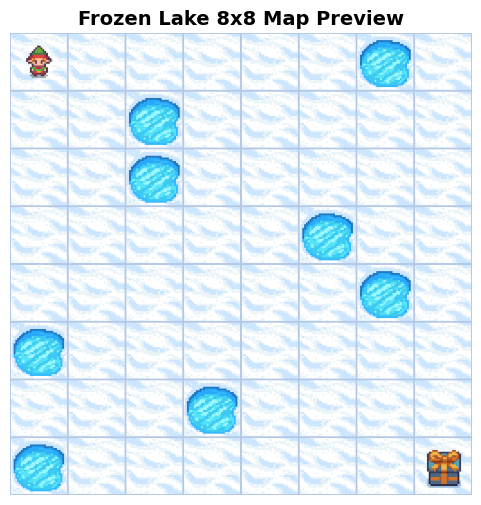

In [109]:
random_map = generate_random_map(size=8, p=0.9) # Generate an 8x8 map that is mathematically guaranteed to be solvable
# p=0.8 means 95% safe ice, 5% holes

env = gym.make('FrozenLake-v1', desc = random_map, is_slippery = True, success_rate = 1.0/3.0, render_mode = 'rgb_array')
first_state, info = env.reset()
frame = env.render()

plt.figure(figsize=(6, 6))
plt.imshow(frame)
plt.axis('off') 
plt.title("Frozen Lake 8x8 Map Preview", fontsize=14, fontweight='bold')
plt.show()


q_table = np.zeros(shape = (env.observation_space.n, env.action_space.n)) # init a 64 x 4 2d Array

learning_rate = 0.01 # alpha
discount_factor = 0.99 # gamma
epsilon = 1.0 # random actions
min_epsilon = 0.1
epsilon_decay_rate = 0.0001
n_episodes = 20000

reward_per_episode = np.zeros(n_episodes)

# Training 

In [110]:
for i in range(n_episodes):
    print(f'Episode {i + 1}')

    state, info = env.reset()
    terminated, truncated = False, False

    reward_in_the_episode = 0

    while (not terminated and not truncated):
        # Policy
        if np.random.random() < epsilon: # Exploration
            action = env.action_space.sample()
        else: # Exploitation
            action = np.argmax(q_table[state])
        # 0: left
        # 1: down 
        # 2: right
        # 3: up
        new_state, reward, terminated, truncated, info =  env.step(action = action)
        reward_in_the_episode += reward

        if terminated:
            target = reward # Just the final reward (0 or 1)
        else:
            target = reward + discount_factor * np.max(q_table[new_state])
        
        q_table[state][action] += learning_rate * (target - q_table[state][action])

        state = new_state
        # print(f'action: {action}, new_state: {new_state}, reward: {reward}, terminated: {terminated}, truncated: {truncated}')

    reward_per_episode[i] = reward_in_the_episode
    epsilon = max(epsilon - epsilon_decay_rate, min_epsilon) # decay epsilon until 0

    if (reward == 1): # At the end of the episode, if we finish - reward = 1
        reward_per_episode[i] = 1

env.close()

Episode 1
Episode 2
Episode 3
Episode 4
Episode 5
Episode 6
Episode 7
Episode 8
Episode 9
Episode 10
Episode 11
Episode 12
Episode 13
Episode 14
Episode 15
Episode 16
Episode 17
Episode 18
Episode 19
Episode 20
Episode 21
Episode 22
Episode 23
Episode 24
Episode 25
Episode 26
Episode 27
Episode 28
Episode 29
Episode 30
Episode 31
Episode 32
Episode 33
Episode 34
Episode 35
Episode 36
Episode 37
Episode 38
Episode 39
Episode 40
Episode 41
Episode 42
Episode 43
Episode 44
Episode 45
Episode 46
Episode 47
Episode 48
Episode 49
Episode 50
Episode 51
Episode 52
Episode 53
Episode 54
Episode 55
Episode 56
Episode 57
Episode 58
Episode 59
Episode 60
Episode 61
Episode 62
Episode 63
Episode 64
Episode 65
Episode 66
Episode 67
Episode 68
Episode 69
Episode 70
Episode 71
Episode 72
Episode 73
Episode 74
Episode 75
Episode 76
Episode 77
Episode 78
Episode 79
Episode 80
Episode 81
Episode 82
Episode 83
Episode 84
Episode 85
Episode 86
Episode 87
Episode 88
Episode 89
Episode 90
Episode 91
Episode 

# Running Diagnostics

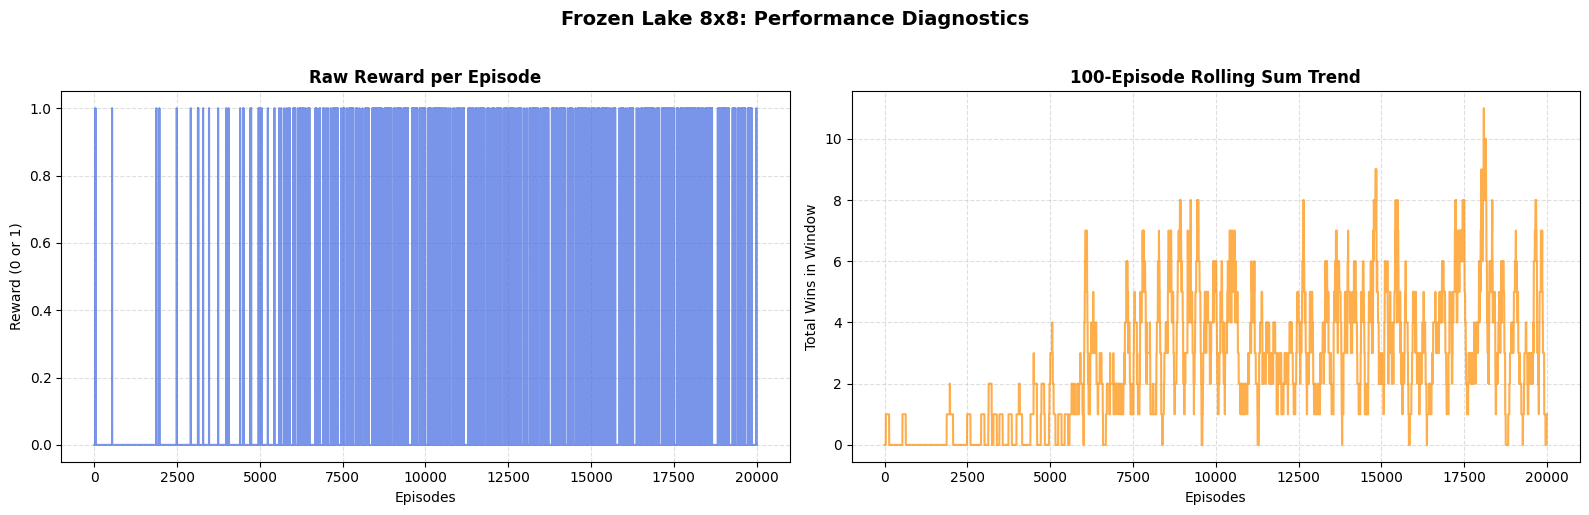

[[5.72059019e-03 7.68669230e-03 5.35474845e-03 5.57253249e-03]
 [5.51760923e-03 5.43622825e-03 7.61056358e-03 5.53030305e-03]
 [2.84885696e-03 3.47316647e-03 3.22939241e-03 7.77984743e-03]
 [4.51947485e-03 5.13393273e-03 8.50253141e-03 4.80100274e-03]
 [9.76564860e-03 3.13762651e-03 3.31603248e-03 3.03598895e-03]
 [2.18300906e-05 1.40250517e-03 2.05208192e-05 1.92520154e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.84163333e-11 4.03583091e-10 1.65840851e-07 9.56485311e-12]
 [5.34042309e-03 4.91830077e-03 8.21223547e-03 4.06727343e-03]
 [7.86139935e-03 3.36421843e-03 3.04438027e-03 2.96360030e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.14364643e-03 2.78700856e-03 4.08436571e-03 2.17709119e-03]
 [1.17234037e-02 3.19576113e-03 2.20846832e-03 1.61111963e-03]
 [7.87413593e-06 1.97180160e-03 1.21292758e-05 4.23858686e-08]
 [7.83978450e-07 1.06452544e-07 1.04803397e-06 9.34866733e-05]
 [1.37284173e-06 2.07720970e-05 2.96458335e-07 4.066324

In [111]:
sum_rewards = np.zeros(n_episodes)
for t in range(n_episodes):
    sum_rewards[t] = np.sum(reward_per_episode[max(0,t-100):(t+1)]) # 100-episode rolling window sum of rewards

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Graph 1: Raw Reward per Episode
ax1.plot(reward_per_episode, color='royalblue', alpha=0.7)
ax1.set_title('Raw Reward per Episode', fontsize=12, fontweight='bold')
ax1.set_xlabel('Episodes')
ax1.set_ylabel('Reward (0 or 1)')
ax1.grid(True, linestyle='--', alpha=0.4) # of the grid in the background

# Graph 2: 100-Episode Rolling Sum
ax2.plot(sum_rewards, color='darkorange', alpha = 0.7)
ax2.set_title('100-Episode Rolling Sum Trend', fontsize=12, fontweight='bold')
ax2.set_xlabel('Episodes')
ax2.set_ylabel('Total Wins in Window')
ax2.grid(True, linestyle='--', alpha=0.4)

# 3. Save and clean up the display layout
plt.suptitle('Frozen Lake 8x8: Performance Diagnostics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout() 
plt.savefig('frozen_lake8x8_separated.png', dpi=300, bbox_inches='tight') 
plt.show()


f = open('frozen_lake8x8.pk1', 'wb')
pickle.dump(q_table,f) # Saving the Q_Table
f.close()


# view the q_table normally
with open('frozen_lake8x8.pk1', 'rb') as f:
    loaded_q_table = pickle.load(f)
print(loaded_q_table)